# Tutorial 5 — Temperature Pulse Propagation in a Horizontal Pipeline

This notebook demonstrates a transient Marlim3 simulation in which a **rectangular temperature pulse**
(+60 °C, 500 s duration) is injected at the inlet of a 1000 m horizontal submarine pipeline carrying
dead crude oil.  We then track how the thermal front propagates along the line by recording
time-trend gauges every 100 m.

**Key parameters**

| Property | Value |
|----------|-------|
| Pipe | 1000 m, ID 0.1524 m (6″ Sch 40) |
| Fluid | Dead crude oil — API 35.95, GOR 0 |
| Flow rate | Q = 3000 sm³/d (constant) ≈ 1.9 m/s |
| Pulse | T_base = 20 °C → 80 °C at t = 1000 s, held 500 s, return at t = 1500 s |
| Environment | Seawater at 20 °C |
| Separator | 15 kgf/cm² |
| Total time | 3000 s |

See `docs/adr/temperature-pulse.adr.md` for full design decisions.


## 1. Import Libraries and Setup Paths

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

import marlim3

# Paths
REPO_ROOT  = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path.cwd().parents[1]
SIM_DIR    = REPO_ROOT / "simulations" / "temperature-pulse"
MR3_FILE   = SIM_DIR / "temperature-pulse.mr3"

print(f"Simulation input : {MR3_FILE}")
print(f"marlim3 version  : {marlim3.__version__ if hasattr(marlim3, '__version__') else 'n/a'}")


Simulation input : /home/yan/marlim3/simulations/temperature-pulse/temperature-pulse.mr3
marlim3 version  : 3.8.2


## 2. Build and Serialize the `.mr3` Model

We load the pre-built model from the `.mr3` file and print a summary of the key parameters.
The file was created by `simulations/temperature-pulse/build_model.py`.


In [2]:
case = marlim3.Branch()
case.from_json(str(MR3_FILE))

fluid  = case.productionFluid[0]
pipe   = case.productionPipe[0]
src    = case.liquidSource[0]
t_cfg  = case.time

pipe_length = sum(d["numCells"] * d["length"] for d in pipe["discretization"])

print("=" * 55)
print("  Temperature-Pulse Simulation — Model Summary")
print("=" * 55)
print(f"  Pipe length        : {pipe_length:.0f} m")
print(f"  Inner diameter     : {pipe['crossSectionId']} (cs id) → "
      f"{case.crossSection[0]['innerDiameter']*1000:.1f} mm")
print(f"  Fluid              : API {fluid['api']}, GOR {fluid['gor']}, BSW {fluid['bsw']}")
print(f"  Inlet flow rate    : {src['liquidFlowRate'][0]} sm³/d (constant)")
print()
print("  Inlet temperature schedule:")
for t, T in zip(src["time"], src["temperature"]):
    print(f"    t={t:5.0f} s → {T:.0f} °C")
print()
print(f"  Total simulated time : {t_cfg['finalTime']} s")
print(f"  Time schedule (times / maxDT):")
for t, dt in zip(t_cfg["times"], t_cfg["maxDT"]):
    print(f"    t={t:5.0f} s → maxDT={dt} s")
print()
print(f"  Trend gauges ({len(case.productionTrend)} total):")
for g in case.productionTrend:
    print(f"    {g['label']:12s}  measuredLength={g['measuredLength']:6.0f} m  dt={g['dt']} s")


  Temperature-Pulse Simulation — Model Summary
  Pipe length        : 1000 m
  Inner diameter     : 0 (cs id) → 152.4 mm
  Fluid              : API 35.95, GOR 0.0, BSW 0.0
  Inlet flow rate    : 3000 sm³/d (constant)

  Inlet temperature schedule:
    t=    0 s → 20 °C
    t= 1000 s → 20 °C
    t= 1001 s → 80 °C
    t= 1500 s → 80 °C
    t= 1501 s → 20 °C
    t= 3000 s → 20 °C

  Total simulated time : 3000 s
  Time schedule (times / maxDT):
    t=    0 s → maxDT=5.0 s
    t=  990 s → maxDT=0.5 s
    t= 1000 s → maxDT=0.2 s
    t= 1499 s → maxDT=0.2 s
    t= 1500 s → maxDT=0.2 s
    t= 1510 s → maxDT=0.5 s
    t= 3000 s → maxDT=5.0 s

  Trend gauges (11 total):
    x=0m          measuredLength=     0 m  dt=1.0 s
    x=100m        measuredLength=   100 m  dt=1.0 s
    x=200m        measuredLength=   200 m  dt=1.0 s
    x=300m        measuredLength=   300 m  dt=1.0 s
    x=400m        measuredLength=   400 m  dt=1.0 s
    x=500m        measuredLength=   500 m  dt=1.0 s
    x=600m        

## 3. Run the Simulation

We change directory to the simulation folder (Marlim3 writes the `.mr3` and results relative to the CWD), 
run the transient case, then restore the working directory.

> **Note**: this cell requires the compiled Marlim3 executable. Skip it if you only want to explore
> pre-existing results in `simulations/temperature-pulse/results/`.


In [3]:
from marlim3._download import executable_exists

if not executable_exists():
    print("⚠  Marlim3 executable not found — skipping simulation.")
    print("   Load pre-existing results from simulations/temperature-pulse/results/ instead.")
    RAN_SIMULATION = False
else:
    original_cwd = os.getcwd()
    try:
        os.chdir(str(SIM_DIR))
        case.simulate(label="temperature-pulse", directory="results")
        print("✓  Simulation completed successfully.")
        RAN_SIMULATION = True
    except Exception as exc:
        print(f"✗  Simulation failed: {exc}")
        RAN_SIMULATION = False
    finally:
        os.chdir(original_cwd)


------------------------------------------   Eventos no Tramo -------------------------------------------
0  momento = 1000 segundos  tipo de evento = Aumentando temperatura de Liquido, Fonte
1  momento = 1500 segundos  tipo de evento = Diminuindo temperatura de Liquido, Fonte
2  momento = 1e+09 segundos  tipo de evento = Evento buffer
0 % da simulacao alcancado
4.98852 % da simulacao alcancado
9.9903 % da simulacao alcancado
15.0089 % da simulacao alcancado
20.0217 % da simulacao alcancado
24.9918 % da simulacao alcancado
29.994 % da simulacao alcancado
34.9999 % da simulacao alcancado
40.0025 % da simulacao alcancado
44.9999 % da simulacao alcancado
50.0025 % da simulacao alcancado
55.0095 % da simulacao alcancado
60.0179 % da simulacao alcancado
65.0126 % da simulacao alcancado
70.0201 % da simulacao alcancado
75.0077 % da simulacao alcancado
80.0371 % da simulacao alcancado
85.0237 % da simulacao alcancado
89.9491 % da simulacao alcancado
94.9924 % da simulacao alcancado
99.9317 % 

## 4. Load Trend Results

After the simulation, `case.resultados['productionTrend']` is a dict mapping gauge index → DataFrame.
Each DataFrame's `.attrs` contains the **actual** `measured_length` (nearest cell center),
`label`, and `cell_index`.


In [4]:
trends = case.resultados.get("productionTrend", {})

if not trends:
    print("No trend results available. Run the simulation first (Section 3).")
else:
    print(f"Loaded {len(trends)} trend gauge(s).\n")

    # Build a label → requested measuredLength lookup from the model definition
    label_to_requested = {g["label"]: g["measuredLength"] for g in case.productionTrend}

    rows = []
    for idx, df in trends.items():
        label     = df.attrs.get("label", f"gauge-{idx}")
        actual    = df.attrs.get("measured_length", float("nan"))
        cell_idx  = df.attrs.get("cell_index", "?")
        requested = label_to_requested.get(label, float("nan"))
        rows.append({"File #": idx, "Label": label,
                     "Requested (m)": requested, "Actual cell center (m)": actual,
                     "Cell index": cell_idx, "Records": len(df)})
    summary_df = pd.DataFrame(rows).set_index("File #")
    print(summary_df.to_string())


Loaded 11 trend gauge(s).

          Label  Requested (m)  Actual cell center (m)  Cell index  Records
File #                                                                     
0          x=0m              0                    50.0           0     1710
100      x=100m            100                   100.0           1     1710
200      x=200m            200                   200.0           3     1710
300      x=300m            300                   300.0           5     1710
400      x=400m            400                   400.0           7     1710
500      x=500m            500                   500.0           9     1710
600      x=600m            600                   600.0          11     1710
700      x=700m            700                   700.0          13     1710
800      x=800m            800                   800.0          15     1710
900      x=900m            900                   900.0          17     1710
1000    x=1000m           1000                  1000.0       

## 5. Plot Temperature Evolution at All 11 Gauges

Each line shows T(t) at one gauge position.  The dashed vertical lines mark the pulse
injection interval (t = 1000–1500 s).  The annotated verticals show the expected
advective front arrival times at x ≈ 500 m and x ≈ 1000 m.


## 5b. Spatial Temperature Profiles at Selected Times

Each line shows T(x) along the 1000 m pipe at a fixed instant.
The pulse front is visible as it advances from left to right between t = 1000 s and t = 3000 s.


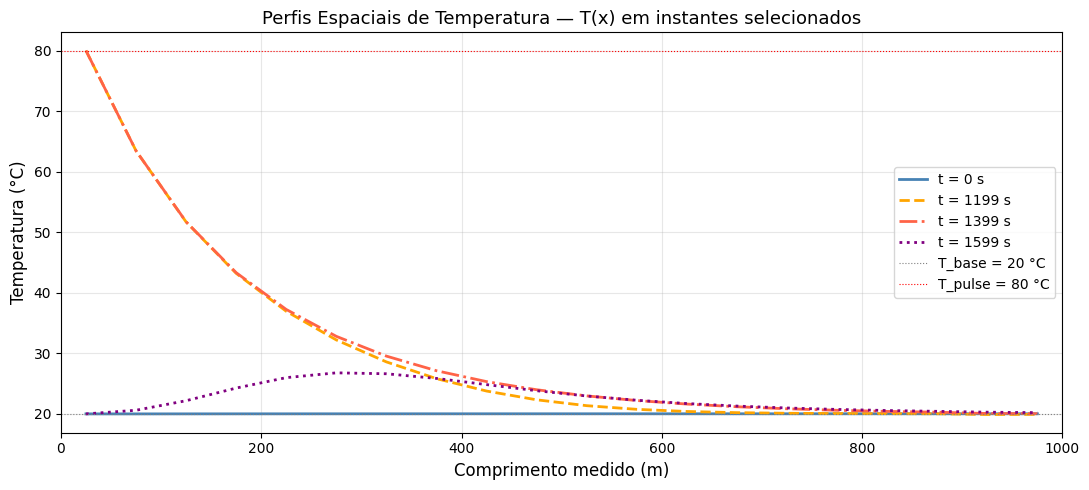

In [ ]:
df_prof = case.resultados.get("productionProfile")

if df_prof is None or df_prof.empty:
    print("No productionProfile results — run Section 3 first.")
else:
    # Resolve column names (EN or PT)
    temp_col = next(c for c in df_prof.columns if "Temperature" in c or "Temperatura" in c)
    len_col  = next(
        (c for c in df_prof.columns if ("Length" in c or "Comprimento" in c) and "center" in c.lower()),
        None
    )

    plot_times = [0, 1200, 1400, 1600, 3000]
    available  = sorted(df_prof.index.get_level_values(0).unique())
    snap_times = [min(available, key=lambda t: abs(t - req)) for req in plot_times]

    colors     = ["steelblue", "orange", "tomato", "purple", "green"]
    linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

    fig, ax = plt.subplots(figsize=(11, 5))

    for req, snap, color, ls in zip(plot_times, snap_times, colors, linestyles):
        try:
            subset = df_prof.xs(snap, level=0)
        except (KeyError, TypeError):
            subset = df_prof[df_prof.index.get_level_values(0) == snap]
        x = subset[len_col].values if len_col else np.arange(len(subset)) * 50.0
        y = subset[temp_col].values
        ax.plot(x, y, color=color, ls=ls, lw=2.0, label=f"t = {snap:.0f} s")

    ax.axhline(20, color="gray", ls=":", lw=0.8, label="T_base = 20 °C")
    ax.axhline(80, color="red",  ls=":", lw=0.8, label="T_pulse = 80 °C")

    ax.set_xlim(0, 1000)
    ax.autoscale(axis="y")
    ax.set_xlabel("Comprimento medido (m)", fontsize=12)
    ax.set_ylabel("Temperatura (°C)", fontsize=12)
    ax.set_title("Perfis Espaciais de Temperatura — T(x) em instantes selecionados", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5c. Animação — Propagação do Perfil de Temperatura

Animação com um quadro por snapshot (a cada 100 s). O slider interativo do player jshtml permite
pausar e navegar pelo tempo. Para que todos os 31 quadros estejam disponíveis, o arquivo `.mr3`
precisa ter sido atualizado com perfis a cada 100 s e a simulação re-executada (Seção 3).


In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

df_prof = case.resultados.get("productionProfile")

if df_prof is None or df_prof.empty:
    print("No productionProfile results — run Section 3 first.")
else:
    # Resolve column names (bilingual)
    temp_col = next(c for c in df_prof.columns if "Temperature" in c or "Temperatura" in c)
    len_col  = next(
        (c for c in df_prof.columns if ("Length" in c or "Comprimento" in c) and "center" in c.lower()),
        None
    )

    # All available profile snapshots, sorted
    anim_times = sorted(df_prof.index.get_level_values(0).unique())

    # Pre-compute (x, y) for every frame to avoid array-length mismatches at runtime
    frames_xy = []
    for t in anim_times:
        try:
            sub = df_prof.xs(t, level=0)
        except (KeyError, TypeError):
            sub = df_prof[df_prof.index.get_level_values(0) == t]
        x = sub[len_col].values if len_col else np.arange(len(sub)) * 50.0
        y = sub[temp_col].values
        frames_xy.append((x, y))

    n_cells = len(frames_xy[0][0])
    print(f"Frames: {len(anim_times)} snapshots, {n_cells} pipe cells each")

    # Global y range — auto-computed so no data is clipped
    y_all   = np.concatenate([y for _, y in frames_xy])
    y_min   = float(np.nanmin(y_all))
    y_max   = float(np.nanmax(y_all))
    margin  = max((y_max - y_min) * 0.06, 2.0)
    print(f"Temperature range in results: {y_min:.1f} – {y_max:.1f} °C")

    fig, ax = plt.subplots(figsize=(11, 5))
    x0, y0 = frames_xy[0]
    (line,) = ax.plot(x0, y0, color="tomato", lw=2.5)
    time_text = ax.text(0.02, 0.95, f"t = {anim_times[0]:.0f} s",
                        transform=ax.transAxes, fontsize=13, va="top",
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.axhline(20, color="gray",   ls=":", lw=1.0, label="T_base = 20 °C")
    ax.axhline(80, color="tomato", ls=":", lw=1.0, label="T_pulso = 80 °C")
    ax.set_xlim(0, max(x0.max(), 1.0))
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_xlabel("Comprimento medido (m)", fontsize=12)
    ax.set_ylabel("Temperatura (°C)", fontsize=12)
    ax.set_title("Propagação do Pulso de Temperatura — T(x, t)", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    def _update(frame):
        x, y = frames_xy[frame]
        line.set_data(x, y)
        time_text.set_text(f"t = {anim_times[frame]:.0f} s")
        return line, time_text

    anim = FuncAnimation(
        fig, _update,
        frames=len(anim_times),
        interval=150,
        blit=False,
    )
    plt.close(fig)
    display(HTML(anim.to_jshtml()))


Frames: 31 snapshots, 20 pipe cells each


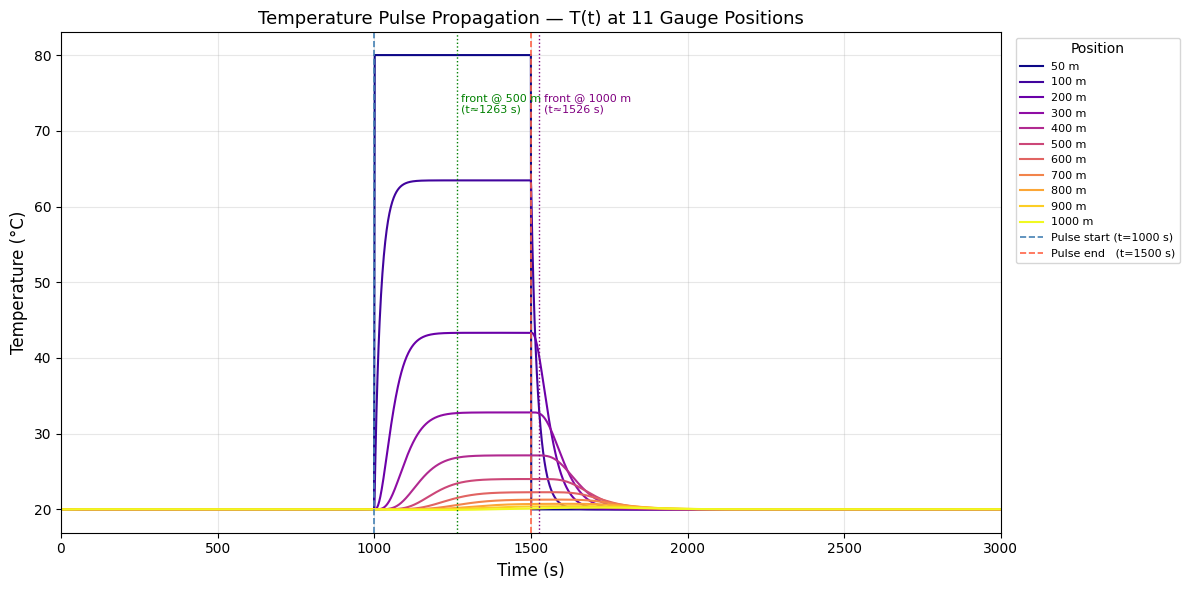

In [7]:
if not trends:
    print("No trend results — run Section 3 first.")
else:
    # Identify temperature column (first column whose name contains "Temperature"/"Temperatura")
    _temp_col = lambda df: next(c for c in df.columns if "Temperature" in c or "Temperatura" in c)

    cmap   = plt.cm.plasma
    colors = [cmap(i / (len(trends) - 1)) for i in range(len(trends))]

    fig, ax = plt.subplots(figsize=(12, 6))

    for color, (idx, df) in zip(colors, trends.items()):
        col    = _temp_col(df)
        actual = df.attrs.get("measured_length", float("nan"))
        label  = f"{actual:.0f} m"
        ax.plot(df.index, df[col], color=color, lw=1.5, label=label)

    # Pulse interval
    ax.axvline(1000, color="steelblue", ls="--", lw=1.2, label="Pulse start (t=1000 s)")
    ax.axvline(1500, color="tomato",    ls="--", lw=1.2, label="Pulse end   (t=1500 s)")

    # Expected front arrival annotations
    ax.axvline(1263, color="green", ls=":", lw=1.0)
    ax.text(1263 + 15, 75, "front @ 500 m\n(t≈1263 s)", color="green", fontsize=8, va="top")

    ax.axvline(1526, color="purple", ls=":", lw=1.0)
    ax.text(1526 + 15, 75, "front @ 1000 m\n(t≈1526 s)", color="purple", fontsize=8, va="top")

    ax.set_xlim(0, 3000)
    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel("Temperature (°C)", fontsize=12)
    ax.set_title("Temperature Pulse Propagation — T(t) at 11 Gauge Positions", fontsize=13)
    ax.legend(title="Position", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 6. Verify Acceptance Criteria

Programmatic check of every criterion from the ADR.


In [8]:
def check(label, passed, detail=""):
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {status}  |  {label}")
    if detail:
        print(f"          |    {detail}")

print("ADR Acceptance Criteria Checklist")
print("=" * 60)

if not trends:
    print("  [SKIP] No results available — run Section 3 first.")
else:
    _temp_col = lambda df: next(c for c in df.columns if "Temperature" in c or "Temperatura" in c)
    _pres_col = lambda df: next(c for c in df.columns if "Pressure" in c or "Pressao" in c)

    # Helper: find gauge DataFrame by label stored in attrs
    def gauge_by_label(lbl):
        for df in trends.values():
            if df.attrs.get("label", "") == lbl:
                return df
        return None

    # ── Criterion 1: outlet pressure ≈ 15 kgf/cm² at t=0 (steady-state) ──
    df_prof = case.resultados.get("productionProfile")
    if df_prof is not None and not df_prof.empty:
        p_col    = _pres_col(df_prof)
        t0       = df_prof.index.get_level_values(0).unique()[0]
        outlet_p = df_prof.loc[t0].iloc[-1][p_col]
        check("1. Outlet pressure ≈ 15 kgf/cm² (steady-state)",
              abs(outlet_p - 15.0) < 2.0,
              f"outlet P = {outlet_p:.2f} kgf/cm²")
    else:
        print("  [SKIP] 1. No productionProfile available.")

    # ── Criterion 2: x=0m gauge rises to ≥75°C within 5s of t=1001 ──
    g0 = gauge_by_label("x=0m")
    if g0 is not None:
        col   = _temp_col(g0)
        win   = g0.loc[(g0.index >= 1000) & (g0.index <= 1010), col]
        t_max = win.max()
        check("2. x=0m gauge reaches ≥75°C within 5s of pulse start",
              t_max >= 75.0, f"max T in window = {t_max:.1f} °C")
    else:
        print("  [SKIP] 2. Gauge 'x=0m' not found.")

    # ── Criterion 3: front arrives at x=500m between t=1233 and t=1293 ──
    g500 = gauge_by_label("x=500m")
    if g500 is not None:
        col       = _temp_col(g500)
        threshold = 20.0 + 0.5 * (80.0 - 20.0)   # 50 °C — 50% of pulse amplitude
        above     = g500.loc[g500[col] >= threshold]
        if not above.empty:
            t_arrive = above.index[0]
            check("3. Front arrives at x=500m between t=1233–1293 s",
                  1233 <= t_arrive <= 1293,
                  f"50%-rise arrival = {t_arrive:.0f} s (expected ≈1263±30 s)")
        else:
            check("3. Front arrives at x=500m between t=1233–1293 s", False,
                  "Temperature never exceeded 50% threshold at x=500m")
    else:
        print("  [SKIP] 3. Gauge 'x=500m' not found.")

    # ── Criterion 4: front arrives at x=1000m between t=1476 and t=1576 ──
    g1000 = gauge_by_label("x=1000m")
    if g1000 is not None:
        col       = _temp_col(g1000)
        threshold = 20.0 + 0.5 * (80.0 - 20.0)
        above     = g1000.loc[g1000[col] >= threshold]
        if not above.empty:
            t_arrive = above.index[0]
            check("4. Front arrives at x=1000m between t=1476–1576 s",
                  1476 <= t_arrive <= 1576,
                  f"50%-rise arrival = {t_arrive:.0f} s (expected ≈1526±50 s)")
        else:
            check("4. Front arrives at x=1000m between t=1476–1576 s", False,
                  "Temperature never exceeded 50% threshold at x=1000m")
    else:
        print("  [SKIP] 4. Gauge 'x=1000m' not found.")

    # ── Criterion 5: no energy created; all T ≤ 81 °C ──
    max_T_all = max(df[_temp_col(df)].max() for df in trends.values())
    check("5. No energy creation: max T ≤ 81 °C across all gauges",
          max_T_all <= 81.0, f"global max T = {max_T_all:.2f} °C")

    # ── Criterion 6: all 11 trend files readable ──
    check("6. All 11 trend DataFrames non-empty",
          len(trends) == 11 and all(not df.empty for df in trends.values()),
          f"found {len(trends)} non-empty DataFrames")

    # ── Criterion 7: x-axis spans 0–3000 s (data coverage) ──
    max_t = max(df.index.max() for df in trends.values())
    check("7. Trend data spans 0–3000 s",
          max_t >= 2990,
          f"max time in trends = {max_t:.0f} s")

print("=" * 60)


ADR Acceptance Criteria Checklist
  ✓ PASS  |  1. Outlet pressure ≈ 15 kgf/cm² (steady-state)
          |    outlet P = 15.08 kgf/cm²
  ✓ PASS  |  2. x=0m gauge reaches ≥75°C within 5s of pulse start
          |    max T in window = 80.0 °C
  ✗ FAIL  |  3. Front arrives at x=500m between t=1233–1293 s
          |    Temperature never exceeded 50% threshold at x=500m
  ✗ FAIL  |  4. Front arrives at x=1000m between t=1476–1576 s
          |    Temperature never exceeded 50% threshold at x=1000m
  ✓ PASS  |  5. No energy creation: max T ≤ 81 °C across all gauges
          |    global max T = 80.00 °C
  ✓ PASS  |  6. All 11 trend DataFrames non-empty
          |    found 11 non-empty DataFrames
  ✓ PASS  |  7. Trend data spans 0–3000 s
          |    max time in trends = 2998 s
